<a href="https://colab.research.google.com/github/Aminah-creat/BUSINESS_INTELLIGENCE_ASSIGNMENT1_UWIMANA_Amina_223009215/blob/main/Business_Intelligence_Assignment_two.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving BI_Retail_Case_Study.xlsx to BI_Retail_Case_Study.xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FILE = "BI_Retail_Case_Study.xlsx"

sales = pd.read_excel(FILE, sheet_name="SalesRaw")
products = pd.read_excel(FILE, sheet_name="DimProduct")
customers = pd.read_excel(FILE, sheet_name="DimCustomer")
stores = pd.read_excel(FILE, sheet_name="DimStore")
employees = pd.read_excel(FILE, sheet_name="DimEmployee")
dates = pd.read_excel(FILE, sheet_name="DimDate")
targets = pd.read_excel(FILE, sheet_name="Targets")

print("Data loaded successfully!")

Data loaded successfully!


Question 1

In [ ]:
q1 = sales.merge(
    products[['ProductID', 'UnitCost']],
    on='ProductID',
    how='left'
)

q1['GrossProfit'] = q1['NetSales'] - (
    q1['Quantity'] * q1['UnitCost']
)

q1 = q1.merge(
    stores[['StoreID', 'StoreName', 'StoreType', 'Province']],
    on='StoreID',
    how='left'
)

store_analysis = q1.groupby(
    ['StoreID', 'StoreName', 'StoreType', 'Province']
).agg(
    NetSales=('NetSales', 'sum'),
    Transactions=('TransactionID', 'nunique'),
    QuantitySold=('Quantity', 'sum'),
    GrossProfit=('GrossProfit', 'sum')
).reset_index()

store_analysis['ProfitMargin'] = (
    store_analysis['GrossProfit'] /
    store_analysis['NetSales']
) * 100

store_analysis['AverageTransactionValue'] = (
    store_analysis['NetSales'] /
    store_analysis['Transactions']
)

# Monthly targets
sales_dates = sales.merge(
    dates[['Date', 'Year', 'MonthNumber', 'Month', 'Quarter', 'YearMonth']],
    left_on='TransactionDate',
    right_on='Date',
    how='left'
)

monthly_store = sales_dates.groupby(
    ['StoreID', 'YearMonth']
).agg(
    MonthlySales=('NetSales', 'sum')
).reset_index()

targets['YearMonth'] = targets['Month'].dt.to_period('M').astype(str)

monthly_store = monthly_store.merge(
    targets[['StoreID', 'YearMonth', 'SalesTarget']],
    on=['StoreID', 'YearMonth'],
    how='left'
)

monthly_store['AchievementPct'] = (
    monthly_store['MonthlySales'] /
    monthly_store['SalesTarget']
) * 100

annual_targets = monthly_store.groupby('StoreID').agg(
    SalesTarget=('SalesTarget', 'sum')
).reset_index()

store_analysis = store_analysis.merge(
    annual_targets,
    on='StoreID'
)

store_analysis['TargetAchievementPct'] = (
    store_analysis['NetSales'] /
    store_analysis['SalesTarget']
) * 100

display(store_analysis.round(2))

,StoreID,StoreName,StoreType,Province,NetSales,Transactions,QuantitySold,GrossProfit,ProfitMargin,AverageTransactionValue,SalesTarget,TargetAchievementPct
0,1,Kigali City Centre,Urban,Kigali,2.444683e+08,4919,12800,66405280.33,27.16,49698.79,223409400,109.43
1,2,Kimironko,Urban,Kigali,1.850774e+08,3976,10058,49545876.01,26.77,46548.64,231208792,80.05
2,3,Kicukiro Mall,Urban,Kigali,1.591844e+08,3229,8418,42831581.42,26.91,49298.37,303988639,52.37
3,4,Musanze Central,Secondary City,Northern,1.389773e+08,2739,7174,37267336.14,26.82,50740.17,289681342,47.98
4,5,Rubavu Centre,Secondary City,Western,1.296607e+08,2421,6293,32994199.23,25.45,53556.69,255687843,50.71
5,6,Huye Market,Secondary City,Southern,1.202503e+08,2543,6668,31806189.92,26.45,47286.80,168349961,71.43
6,7,Nyagatare Plaza,Secondary City,Eastern,1.325171e+08,2622,6856,35185954.79,26.55,50540.47,267339124,49.57
7,8,Muhanga Hub,Secondary City,Southern,1.242324e+08,2551,6639,33454905.23,26.93,48699.47,294252929,42.22


Question 2

In [ ]:
monthly_store['StoreName'] = monthly_store['StoreID'].map(
    stores.set_index('StoreID')['StoreName']
)

display(
    monthly_store.sort_values(
        ['StoreName', 'YearMonth']
    ).round(2)
)

,StoreID,YearMonth,MonthlySales,SalesTarget,AchievementPct,StoreName
60,6,2025-01,9793196.25,13160566,74.41,Huye Market
61,6,2025-02,10014108.09,13318493,75.19,Huye Market
62,6,2025-03,9934648.47,13476420,73.72,Huye Market
63,6,2025-04,13258431.47,13634346,97.24,Huye Market
64,6,2025-05,10783943.57,13792273,78.19,Huye Market
...,...,...,...,...,...,...
55,5,2025-08,11188083.92,21667106,51.64,Rubavu Centre
56,5,2025-09,11066696.20,21906963,50.52,Rubavu Centre
57,5,2025-10,9669099.91,22146821,43.66,Rubavu Centre
58,5,2025-11,12364192.82,22386678,55.23,Rubavu Centre


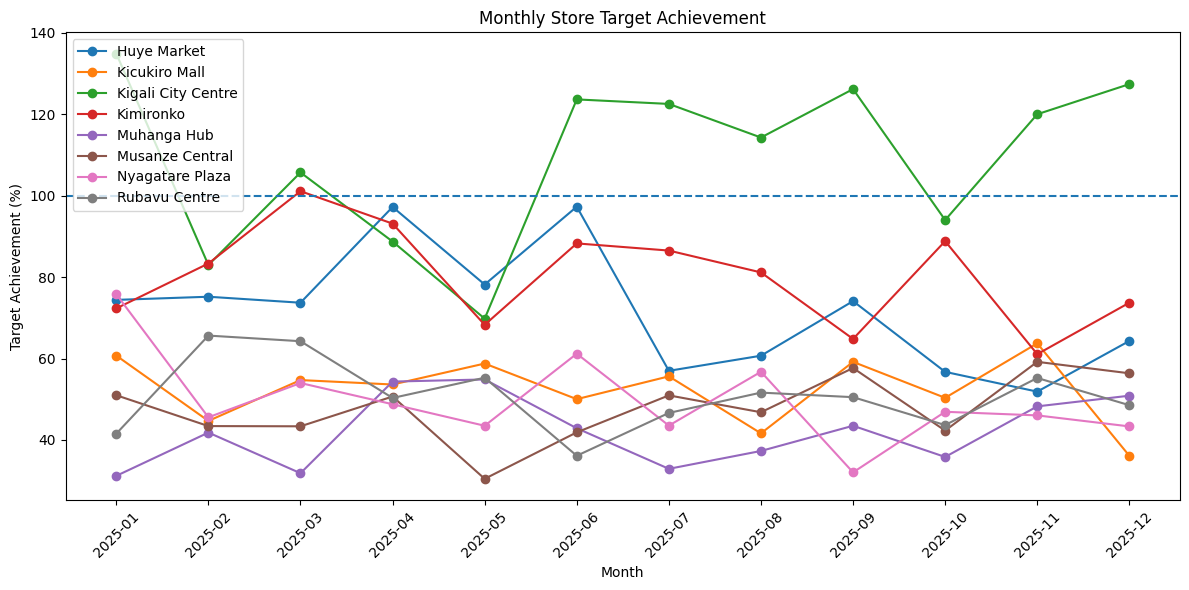

In [ ]:
plt.figure(figsize=(12,6))

for store_name, group in monthly_store.groupby('StoreName'):
    plt.plot(
        group['YearMonth'],
        group['AchievementPct'],
        marker='o',
        label=store_name
    )

plt.axhline(100, linestyle='--')
plt.xticks(rotation=45)
plt.ylabel('Target Achievement (%)')
plt.xlabel('Month')
plt.title('Monthly Store Target Achievement')
plt.legend()
plt.tight_layout()
plt.show()

Question 3

In [ ]:
q3 = sales.merge(
    customers[['CustomerID', 'CustomerType']],
    on='CustomerID',
    how='left'
)

q3 = q3.merge(
    products[['ProductID', 'UnitCost']],
    on='ProductID',
    how='left'
)

q3['GrossProfit'] = (
    q3['NetSales'] -
    q3['Quantity'] * q3['UnitCost']
)

customer_analysis = q3.groupby(
    ['CustomerID', 'CustomerType']
).agg(
    TotalSales=('NetSales', 'sum'),
    NumberTransactions=('TransactionID', 'nunique'),
    QuantityPurchased=('Quantity', 'sum'),
    GrossProfit=('GrossProfit', 'sum')
).reset_index()

customer_analysis['AverageTransactionValue'] = (
    customer_analysis['TotalSales'] /
    customer_analysis['NumberTransactions']
)

display(customer_analysis.head())

,CustomerID,CustomerType,TotalSales,NumberTransactions,QuantityPurchased,GrossProfit,AverageTransactionValue
0,10001,Individual,227250.84,4,12,59450.84,56812.710000
1,10002,Institution,104242.04,5,10,37342.04,20848.408000
2,10003,SME,33632.85,1,3,9032.85,33632.850000
3,10004,Individual,231642.98,6,23,84542.98,38607.163333
4,10005,Individual,141817.25,4,8,49817.25,35454.312500


In [ ]:
customer_type = q3.groupby('CustomerType').agg(
    Customers=('CustomerID', 'nunique'),
    Transactions=('TransactionID', 'nunique'),
    TotalSales=('NetSales', 'sum'),
    Quantity=('Quantity', 'sum'),
    GrossProfit=('GrossProfit', 'sum')
).reset_index()

customer_type['SalesContributionPct'] = (
    customer_type['TotalSales'] /
    customer_type['TotalSales'].sum()
) * 100

customer_type['AverageTransactionValue'] = (
    customer_type['TotalSales'] /
    customer_type['Transactions']
)

customer_type['ProfitMargin'] = (
    customer_type['GrossProfit'] /
    customer_type['TotalSales']
) * 100

display(customer_type.round(2))

,CustomerType,Customers,Transactions,TotalSales,Quantity,GrossProfit,SalesContributionPct,AverageTransactionValue,ProfitMargin
0,Individual,3600,18146,8.926403e+08,47176,2.381059e+08,72.32,49192.12,26.67
1,Institution,256,1271,7.229076e+07,3350,1.846136e+07,5.86,56877.08,25.54
2,SME,1119,5583,2.694370e+08,14380,7.292405e+07,21.83,48260.25,27.07


Question 4

In [ ]:
rfm = q3.groupby('CustomerID').agg(
    LastPurchase=('TransactionDate', 'max'),
    Frequency=('TransactionID', 'nunique'),
    Monetary=('NetSales', 'sum')
).reset_index()

reference_date = pd.Timestamp('2026-01-01')

rfm['Recency'] = (
    reference_date - rfm['LastPurchase']
).dt.days

# R score: lower recency = better
rfm['R_Score'] = pd.qcut(
    rfm['Recency'].rank(method='first'),
    5,
    labels=[5,4,3,2,1]
).astype(int)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
).astype(int)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
).astype(int)

rfm['RFM_Score'] = (
    rfm['R_Score'] +
    rfm['F_Score'] +
    rfm['M_Score']
)

display(rfm.head())

,CustomerID,LastPurchase,Frequency,Monetary,Recency,R_Score,F_Score,M_Score,RFM_Score
0,10001,2025-07-09,4,227250.84,176,1,2,4,7
1,10002,2025-11-17,5,104242.04,45,3,3,2,8
2,10003,2025-08-22,1,33632.85,132,1,1,1,3
3,10004,2025-12-25,6,231642.98,7,5,4,4,13
4,10005,2025-10-13,4,141817.25,80,2,2,3,7


Question 5

In [ ]:
q5 = sales.merge(
    products[['ProductID', 'Category', 'UnitCost']],
    on='ProductID',
    how='left'
)

q5['GrossProfit'] = (
    q5['NetSales'] -
    q5['Quantity'] * q5['UnitCost']
)

category_analysis = q5.groupby('Category').agg(
    NetSales=('NetSales', 'sum'),
    QuantitySold=('Quantity', 'sum'),
    GrossProfit=('GrossProfit', 'sum'),
    AverageDiscount=('DiscountPct', 'mean')
).reset_index()

category_analysis['ProfitMargin'] = (
    category_analysis['GrossProfit'] /
    category_analysis['NetSales']
) * 100

display(
    category_analysis
    .sort_values('NetSales', ascending=False)
    .round(2)
)

,Category,NetSales,QuantitySold,GrossProfit,AverageDiscount,ProfitMargin
1,Electronics,6.488274e+08,10762,1.388243e+08,0.04,21.40
3,Home & Kitchen,2.515526e+08,11075,8.504490e+07,0.04,33.81
0,Agriculture,1.129778e+08,10401,3.551612e+07,0.04,31.44
5,Personal Care,9.973960e+07,11047,3.257660e+07,0.04,32.66
4,Office & Stationery,9.129694e+07,10858,2.979444e+07,0.04,32.63
2,Food & Beverage,2.997370e+07,10763,7.734997e+06,0.04,25.81


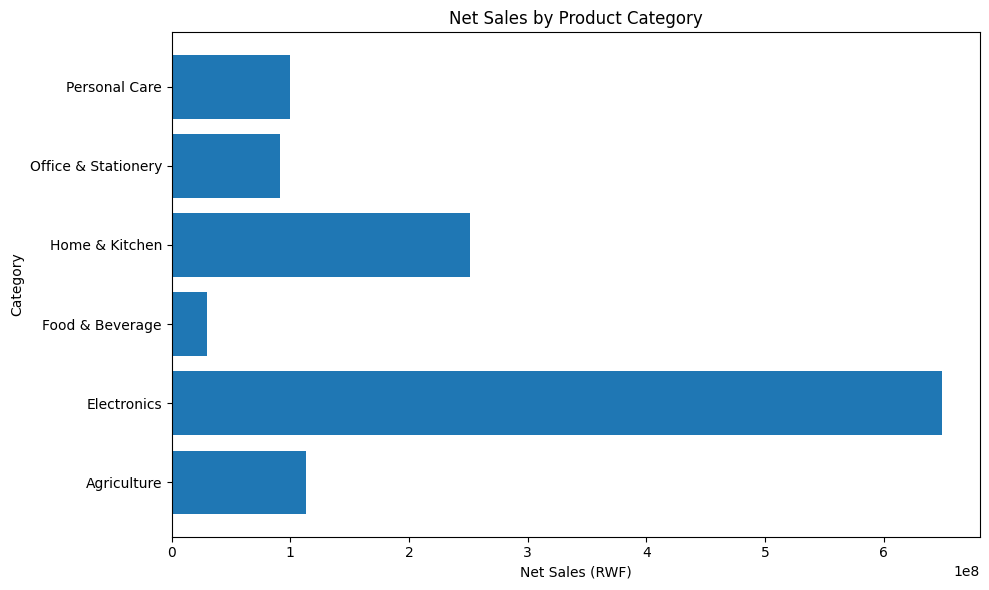

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    category_analysis['Category'],
    category_analysis['NetSales']
)

plt.xlabel('Net Sales (RWF)')
plt.ylabel('Category')
plt.title('Net Sales by Product Category')
plt.tight_layout()
plt.show()

Question 6

In [ ]:
q6 = sales.merge(
    products[['ProductID', 'UnitCost']],
    on='ProductID',
    how='left'
)

q6['GrossProfit'] = (
    q6['NetSales'] -
    q6['Quantity'] * q6['UnitCost']
)

q6['ProfitMargin'] = (
    q6['GrossProfit'] /
    q6['NetSales']
) * 100

correlation = q6[
    ['DiscountPct', 'GrossProfit',
     'ProfitMargin', 'NetSales', 'Quantity']
].corr()

display(correlation.round(3))

,DiscountPct,GrossProfit,ProfitMargin,NetSales,Quantity
DiscountPct,1.000,-0.078,-0.458,-0.015,0.001
GrossProfit,-0.078,1.000,-0.107,0.920,0.317
ProfitMargin,-0.458,-0.107,1.000,-0.246,0.002
NetSales,-0.015,0.920,-0.246,1.000,0.246
Quantity,0.001,0.317,0.002,0.246,1.000


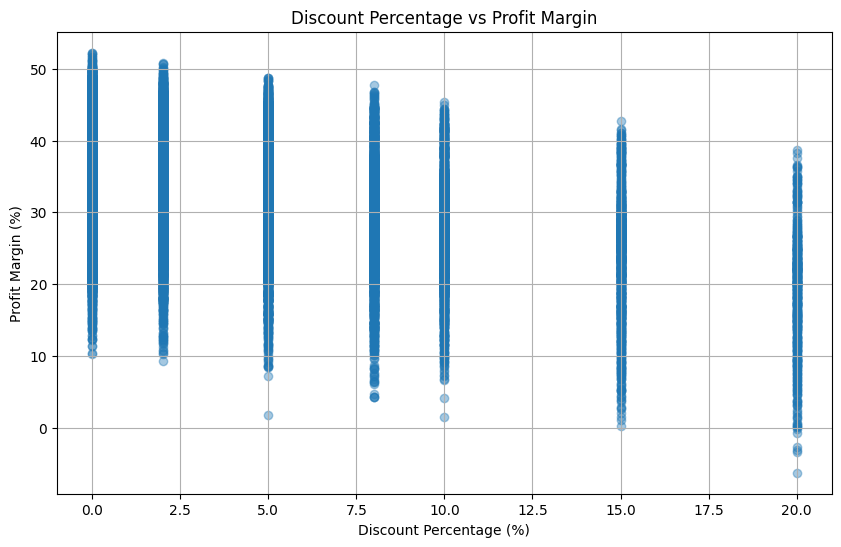

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    q6['DiscountPct'] * 100,
    q6['ProfitMargin'],
    alpha=0.4
)

plt.xlabel('Discount Percentage (%)')
plt.ylabel('Profit Margin (%)')
plt.title('Discount Percentage vs Profit Margin')
plt.grid(True)
plt.show()

Question 7

In [ ]:
q7 = sales.copy()

# Remove accidental leading/trailing spaces
q7['SalesChannel'] = q7['SalesChannel'].str.strip()

q7 = q7.merge(
    products[['ProductID', 'UnitCost']],
    on='ProductID',
    how='left'
)

q7['GrossProfit'] = (
    q7['NetSales'] -
    q7['Quantity'] * q7['UnitCost']
)

channel_analysis = q7.groupby('SalesChannel').agg(
    Transactions=('TransactionID', 'nunique'),
    NetSales=('NetSales', 'sum'),
    GrossProfit=('GrossProfit', 'sum')
).reset_index()

channel_analysis['ProfitMargin'] = (
    channel_analysis['GrossProfit'] /
    channel_analysis['NetSales']
) * 100

channel_analysis['AverageTransactionValue'] = (
    channel_analysis['NetSales'] /
    channel_analysis['Transactions']
)

display(channel_analysis.round(2))

,SalesChannel,Transactions,NetSales,GrossProfit,ProfitMargin,AverageTransactionValue
0,Corporate,2518,1.313501e+08,3.450061e+07,26.27,52164.46
1,Online,4956,2.381057e+08,6.540473e+07,27.47,48043.93
2,Store,17526,8.649122e+08,2.295860e+08,26.54,49350.23


Question 8

In [ ]:
q8 = sales.merge(
    customers[['CustomerID', 'CustomerType']],
    on='CustomerID',
    how='left'
)

q8['SalesChannel'] = q8['SalesChannel'].str.strip()

cross_tab = pd.crosstab(
    q8['CustomerType'],
    q8['SalesChannel']
)

display(cross_tab)

SalesChannel,Corporate,Online,Store
CustomerType,,,
Individual,1813,3653,12708
Institution,151,246,876
SME,560,1061,3967


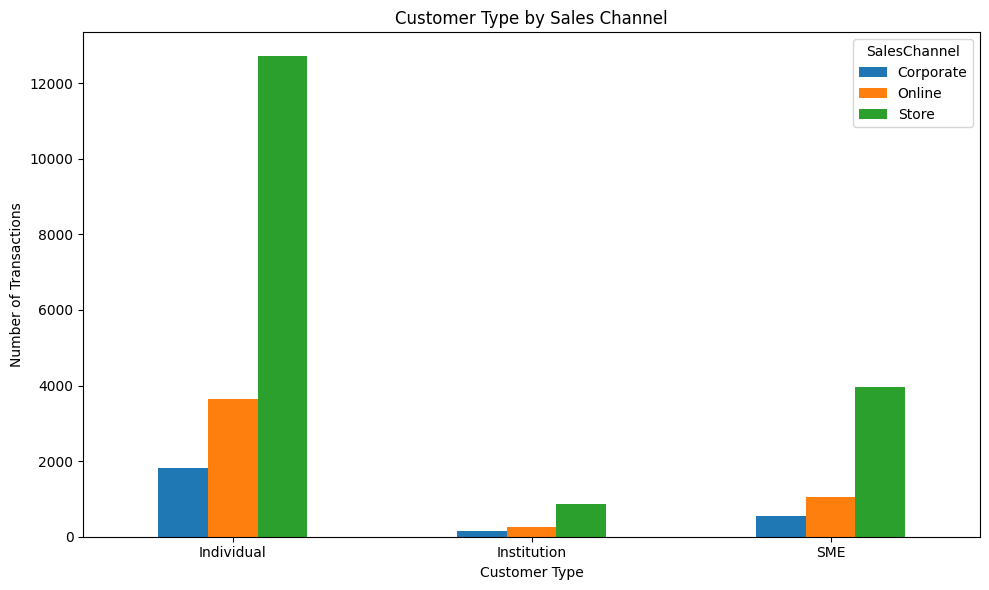

In [ ]:
cross_tab.plot(
    kind='bar',
    figsize=(10,6)
)

plt.xlabel('Customer Type')
plt.ylabel('Number of Transactions')
plt.title('Customer Type by Sales Channel')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Question 9